In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CaFAnalysis import PlotStyle, PlottingTools
from collections import defaultdict
PlotStyle.set_plot_style()
import math

### Get new sequence start from axial cooling

### Input parameters

In [2]:
# Power at 500 mVPP in mW
pwr_RB1 = 45.2
pwr_RB2 = 60
pwr_RB3 = 57.6
pwr_RB4 = 93.8
pwr_CO = 107

RB_powers = np.array([pwr_RB1, pwr_RB2, pwr_RB3, pwr_RB4])

# CO-prop pi time in seconds
pi_time_CO =13.3e-6



# AOM diffraction efficiency, measure power before and after AOM
eta_RB1 = np.sqrt(395 / 1300)  # double pass
eta_RB2 = 114 / 220
eta_RB3 = 103 / 168
eta_RB4 = 240 / 490

etas = np.array([eta_RB1, eta_RB2, eta_RB3, eta_RB4])

# AOM device constants
rf_power = 0.5**2  # RF power proportional to VPP^2
max_eff = 0.85
device_constant = np.arcsin(np.sqrt(etas / max_eff)) / np.sqrt(rf_power)

print("AOM efficiencies:", etas)
print("AOM device constants:", device_constant)

AOM efficiencies: [0.55122242 0.51818182 0.61309524 0.48979592]
AOM device constants: [1.87233931 1.7918434  2.02926678 1.72385422]


### The Rabi to power conversion is different at the three axis
### Get this difference from 2025/09/24 data

In [3]:
pi_times_co_ref = 12e-6
pwr_co_ref = 82
# X, Y, Z
pi_times_axis = np.array([35e-6, 40e-6, 55e-6])
pwr_axis = np.array([38, 46, 84])

pwr_scales = pwr_axis/pwr_co_ref
rb_scales = pi_times_co_ref/pi_times_axis/pwr_scales
print(rb_scales)

[0.73984962 0.53478261 0.21298701]


### AOM diffraction efficiency

In [4]:
def diffracton_efficiency(VPP, device_constant, passes=1):
    efficiency = max_eff**passes * np.sin(device_constant * VPP) ** 2**passes
    return efficiency

In [5]:
def rb_power(index, Vpp):
    if index == 0:
        pwr = diffracton_efficiency(Vpp, device_constant[index], passes=2) * RB_powers[0]\
              / diffracton_efficiency(0.5, device_constant[index], passes=2)
        return pwr
    else:
        pwr = diffracton_efficiency(Vpp, device_constant[index], passes=1)\
            * RB_powers[index]\
            / diffracton_efficiency(0.5, device_constant[index], passes=1)
        return pwr

In [6]:
# Scale power to Rabi frequency
Rabi_scale = np.pi / (np.sqrt(pwr_CO * rb_power(0, 0.92)) * pi_time_CO)
print("Rabi scale (rad/s/sqrt(mW)):", Rabi_scale)

Rabi scale (rad/s/sqrt(mW)): 2254.163580483775


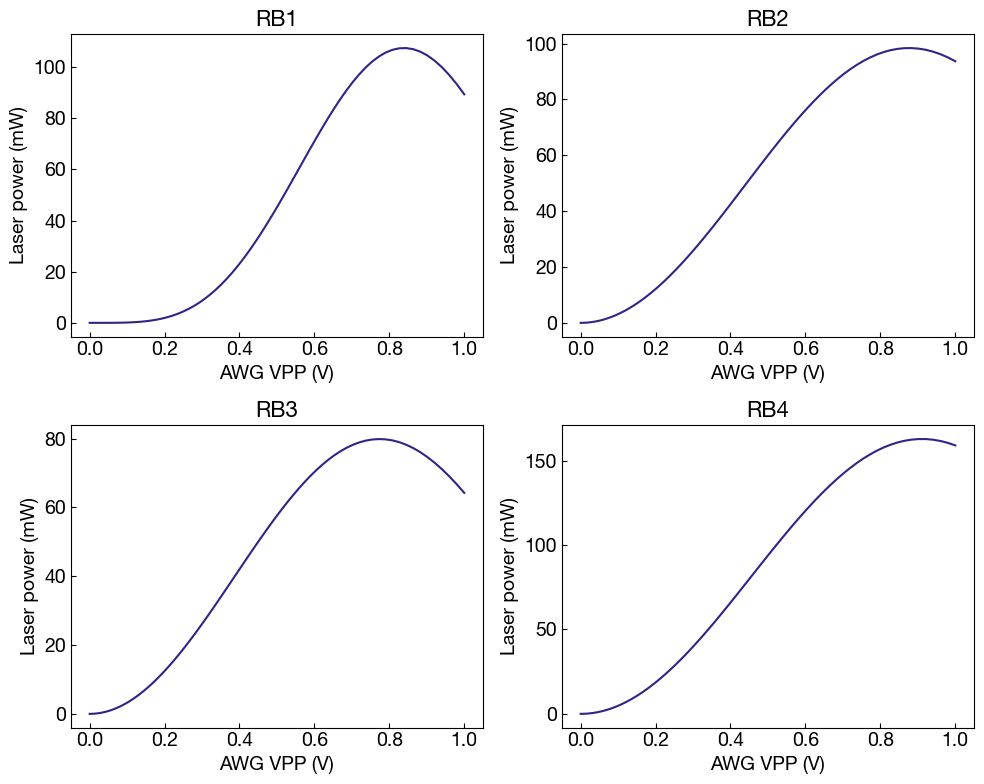

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
for i in range(4):
    VPPs = np.linspace(0, 1, 100) ** 2
    laser_powers = np.array([rb_power(i, p) for p in VPPs])
    ax[i // 2, i % 2].plot(VPPs, laser_powers, '-')
    ax[i // 2, i % 2].set_title(f"RB{i+1}", fontsize=16)
    ax[i // 2, i % 2].set_xlabel("AWG VPP (V)", fontsize=14)
    ax[i // 2, i % 2].set_ylabel("Laser power (mW)", fontsize=14)
    ax[i // 2, i % 2].tick_params(axis="both", which="major", labelsize=14)
    ax[i // 2, i % 2].grid()

plt.tight_layout()

In [8]:
def Rabi_to_VPP(Rabi_target, axis, ch0_amp=0.92):
    """
    Parameters
    ----------
    Rabi_target : float
        Target Rabi frequency in rad/s
    axis : int
        0, 1, 2 for X, Y, Z  (maps to RB2, RB3, RB4)
    ch0_amp : float
        RB1 AWG VPP used during the interaction

    Returns
    -------
    VPP : float
        Required AWG peak-to-peak voltage (V).
        Returns 1.0 if no physical solution exists.
    """

    # Map axis -> RB index
    i = axis + 1  # RB2, RB3, RB4

    # RB1 power during interaction
    rb1_pwr = rb_power(0, ch0_amp)

    # Required RB_i power
    P_target = (Rabi_target / Rabi_scale / rb_scales[i-1]) ** 2 / rb1_pwr

    # Voltage search grid (dense, monotonic region)
    V_grid = np.linspace(0.0, 1.0, 5000)
    P_grid = rb_power(i, V_grid)

    # Check reachability
    if P_target < 0 or P_target > np.max(P_grid):
        return 1.0

    # Find solution (lowest VPP)
    idx = np.argmin(np.abs(P_grid - P_target))
    VPP = V_grid[idx]

    return VPP


### Get amp matrix

In [9]:
def get_amp_matrix(seq_file="original.npy", rabi_scale=[1, 1, 1]):
    seq = np.load(seq_file)
    pulse_list = np.unique(seq, axis=0)

    # Temporary storage for raw delta_n before reindexing
    raw_axes = {
        "0": {0: 0.92},  # default value
        "X": {0: 0.3, 1: 0.65, 2: 0.65, "T": 0.3},
        "Y": {0: 0.3, 1: 0.65, 2: 0.65, "T": 0.3},
        "Z": {
            0: 0.14,
            1: 0.14,
            2: 0.2,
            3: 0.28,
            4: 0.28,
            5: 0,
            6: 0,
            7: 0,
            8: 0,
            9: 0,
            "T": 0.06,
        },
    }

    # Loop through pulses
    for pulse in pulse_list:
        axis_id = int(pulse[0])
        delta_n = -int(pulse[1]) - 1 # Keep the convension
        target_Omega = pulse[2] * rabi_scale[axis_id]

        # Compute VPP
        VPP = Rabi_to_VPP(target_Omega * 2 * np.pi, axis_id) # Convert to radial frequency

        # Map axis id to name
        if axis_id == 0:
            axis = "X"
        elif axis_id == 1:
            axis = "Y"
        elif axis_id == 2:
            axis = "Z"
        else:
            print("Error: invalid axis")
            return None

        raw_axes[axis][delta_n] = float(np.round(VPP, 4))

    return raw_axes

In [10]:
def get_duration_matrix(seq_file="original.npy"):
    seq = np.load(seq_file)
    pulse_list = np.unique(seq, axis=0)
    duration_matrix = {
        "OP": [50e-6],
        "CO": [12e-6],
        "X": {0: 5e-5, 1: 7e-5, 2: 7e-5, "T": 75e-6},
        "Y": {0: 5e-5, 1: 7e-5, 2: 7e-5, "T": 75e-6},
        "Z": {
            0: 2e-4,
            1: 2e-4,
            2: 2e-4,
            3: 5e-5,
            4: 5e-5,
            5: 0,
            6: 0,
            7: 0,
            8: 0,
            9: 0,
            "T": 350 * 1e-6,
        },
    }


    # Loop through pulses
    for pulse in pulse_list:
        axis_id = int(pulse[0])
        delta_n = -int(pulse[1]) - 1 # Keep the convension
        duration = pulse[3]

        # Map axis id to name
        if axis_id == 0:
            axis = "X"
        elif axis_id == 1:
            axis = "Y"
        elif axis_id == 2:
            axis = "Z"
        else:
            print("Error: invalid axis")
            return None

        duration_matrix[axis][delta_n] = float(np.round(duration, 6))


    return duration_matrix

In [11]:
def get_rabi_frquency(axis, amp):
    """
    Parameters
    ----------
    amp : float
        AWG peak-to-peak voltage (V)
    axis : int
        0, 1, 2 for X, Y, Z  (maps to RB2, RB3, RB4)

    Returns
    -------
    Rabi : float
        Rabi frequency in rad/s
    """

    # Map axis -> RB index
    i = axis + 1  # RB2, RB3, RB4

    # Laser power on this RB axis
    rb_pwr = rb_power(i, amp)

    # Rabi frequency (rad/s)
    Rabi = Rabi_scale * np.sqrt(rb_power(0, 0.92) * rb_pwr) * rb_scales[i-1]

    return Rabi


### Get amp and duration from optimzed sequence

In [12]:
# sequence = "gen_18.npy"

# amp_matrix = get_amp_matrix(sequence, rabi_scale=[1, 1, 1])
# duration_matrix = get_duration_matrix(sequence)

In [16]:
get_rabi_frquency(2, 0.8)/2/np.pi

np.float64(9695.1052224516)

### ZT $\Omega$

In [ ]:
get_rabi_frquency(2, 0.06)/2/np.pi

np.float64(1019.6709813215813)